In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms

# Load the CIFAR-100 dataset
dataset = datasets.CIFAR100(root='./data', train=True, download=True, transform=transforms.ToTensor())

# Get an image and label from the dataset
image, label = dataset[100]  # Index 0, you can change this to view different images

# Convert the image tensor to a numpy array and rearrange dimensions for matplotlib
image_np = image.permute(1, 2, 0).numpy()  # Change from (C, H, W) to (H, W, C)

# Display the image with matplotlib
plt.imshow(image_np)
plt.title(f"Label: {label} (Class Index)")
plt.axis('off')
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from model import LeNet5
from tqdm import tqdm

full_train_dataset = datasets.CIFAR100(root='./data', train=True, download=True, transform=transforms.ToTensor())

train_size = 0.8  # 80% for training
val_size = 1 - train_size  # 20% for validation

train_dataset, val_dataset = random_split(full_train_dataset, (train_size, val_size))

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LeNet5(num_classes=100).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_loss, train_acc, eval_loss, eval_acc = model.fit(train_loader, 5, criterion, optimizer, device, val_dataset, save_every=2)


In [9]:
import itertools

search_space = {
    "lr": np.linspace(1e-5, 1e-3, 100),  # Min and max for learning rate
    "weight_decay": np.linspace(0, 0.1, 100),  # Min and max for weight decay
    "betas": itertools.product(np.linspace(0.8, 0.9, 10), np.linspace(0.99, 0.999, 10)),  # Min and max for betas
}

keys, values = zip(*search_space.items())
param_combinations = [v for v in itertools.product(*values)]

In [12]:
a = np.array([(0, 1), (10, 20)])

for x in a:
    print(x) 

[0 1]
[10 20]


In [5]:
import numpy as np
for i in itertools.product(np.linspace(0, 1, 10), np.linspace(10, 100, 10)):
    print(i)

(np.float64(0.0), np.float64(10.0))
(np.float64(0.0), np.float64(20.0))
(np.float64(0.0), np.float64(30.0))
(np.float64(0.0), np.float64(40.0))
(np.float64(0.0), np.float64(50.0))
(np.float64(0.0), np.float64(60.0))
(np.float64(0.0), np.float64(70.0))
(np.float64(0.0), np.float64(80.0))
(np.float64(0.0), np.float64(90.0))
(np.float64(0.0), np.float64(100.0))
(np.float64(0.1111111111111111), np.float64(10.0))
(np.float64(0.1111111111111111), np.float64(20.0))
(np.float64(0.1111111111111111), np.float64(30.0))
(np.float64(0.1111111111111111), np.float64(40.0))
(np.float64(0.1111111111111111), np.float64(50.0))
(np.float64(0.1111111111111111), np.float64(60.0))
(np.float64(0.1111111111111111), np.float64(70.0))
(np.float64(0.1111111111111111), np.float64(80.0))
(np.float64(0.1111111111111111), np.float64(90.0))
(np.float64(0.1111111111111111), np.float64(100.0))
(np.float64(0.2222222222222222), np.float64(10.0))
(np.float64(0.2222222222222222), np.float64(20.0))
(np.float64(0.222222222222

In [ ]:
import matplotlib.pyplot as plt

def plot_metric(metric, **kwargs):
    plt.plot(range(len(metric)), metric, **kwargs)
    plt.xlabel("Epochs")
    plt.grid(True)


plot_metric(train_loss, marker="x")
plot_metric(eval_loss)
plt.ylabel("Loss")

Files already downloaded and verified


Training progress:  50%|█████     | 1/2 [00:20<00:20, 20.64s/it]

Evaluation loss:     4.587615491867256
Evaluation accuracy: 2.89%


Training progress: 100%|██████████| 2/2 [00:41<00:00, 20.75s/it]

Evaluation loss:     4.570749627910789
Evaluation accuracy: 4.88%
Checkpoint saved at Checkpoints\2024_12_24__23-55-10.pth


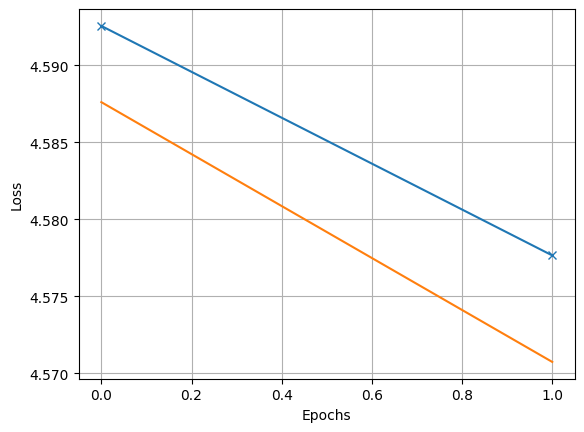

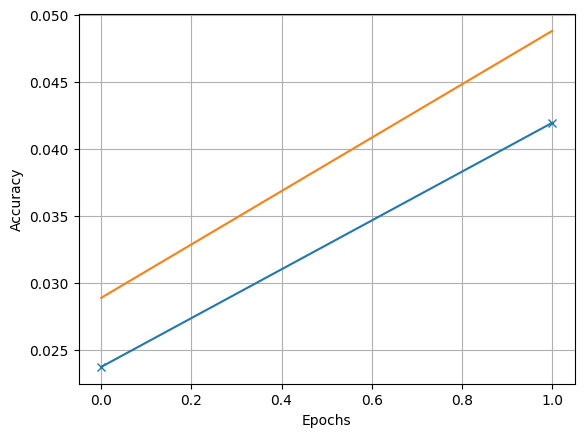

In [13]:
import main

main.main(2)

In [ ]:
def split_N_ways(train_data, N, random_seed=None):
    if random_seed is not None:
        random_seed = torch.Generator().manual_seed(random_seed)

    lengths = [len(train_data) / N] * N

    return random_split(train_data, lengths, random_seed)

def synchronize_models(models: list[torch.nn.Module]):
    #TODO
    pass

In [ ]:
# testing
test_dataset = datasets.CIFAR100(root='./data', train=False, download=True, transform=transforms.ToTensor())


test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

model.evaluate(model, test_loader, device)